In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('../data/processed/finale_clean.csv')
df['Net_Exports'] = df['exports'] - df['imports']
df = df.drop(columns=['exports','imports'])
df = df.sort_values(['country','date']).reset_index(drop=True)

In [3]:
df = df.drop(columns=['countryiso3code'])

In [4]:
for col in ['gdp_growth','inf','ump','fdi']:
    df[f'{col}_lag1'] = df.groupby('country')[col].shift(1)
    df[f'{col}_roll3'] = df.groupby('country')[col].transform(lambda x: x.shift(1).rolling(3).mean())

In [5]:
df = df.dropna(subset=[c for c in df.columns if 'lag1' in c or 'roll3' in c])

In [7]:
# Option 2: Target Encoding (K-Fold, avoids leakage) — better for this project
from sklearn.model_selection import KFold

df['country_target_enc'] = np.nan
kf = KFold(n_splits=5, shuffle=False)  # shuffle=False since time-ordered

for train_idx, val_idx in kf.split(df):
    train_fold = df.iloc[train_idx]
    val_fold = df.iloc[val_idx]
    means = train_fold.groupby('country')['gdp_growth'].mean()
    df.loc[df.index[val_idx], 'country_target_enc'] = df.iloc[val_idx]['country'].map(means)

# fill any leftover NaN (unseen country in a fold) with global mean
df['country_target_enc'] = df['country_target_enc'].fillna(df['gdp_growth'].mean())

df = df.drop(columns=['country'])

In [8]:
df.isnull().sum()   # check
# impute or drop remaining NaNs (decide based on %)

date                    0
gdp_growth              3
inf                    20
ump                     4
pop                     0
fdi                   171
capital               541
govt                  580
Net_Exports           518
gdp_growth_lag1         0
gdp_growth_roll3        0
inf_lag1                0
inf_roll3               0
ump_lag1                0
ump_roll3               0
fdi_lag1                0
fdi_roll3               0
country_target_enc      0
dtype: int64

In [9]:
df = df.dropna(subset=['gdp_growth'])

In [10]:
df.isnull().sum()   # check


date                    0
gdp_growth              0
inf                    19
ump                     4
pop                     0
fdi                   168
capital               538
govt                  577
Net_Exports           515
gdp_growth_lag1         0
gdp_growth_roll3        0
inf_lag1                0
inf_roll3               0
ump_lag1                0
ump_roll3               0
fdi_lag1                0
fdi_roll3               0
country_target_enc      0
dtype: int64

In [11]:
train = df[df['date'] < 2020]
test = df[df['date'] >= 2020]

X_train, y_train = train.drop(columns=['gdp_growth']), train['gdp_growth']
X_test, y_test = test.drop(columns=['gdp_growth']), test['gdp_growth']

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.select_dtypes(include=np.number))
X_test_scaled = scaler.transform(X_test.select_dtypes(include=np.number))

In [16]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tscv = TimeSeriesSplit(n_splits=5)
params = {'n_estimators':[100,200,300], 'max_depth':[3,5,7], 'learning_rate':[0.01,0.05,0.1]}

grid = GridSearchCV(XGBRegressor(random_state=42), params, cv=tscv, scoring='r2', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_
print(grid.best_params_)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}


In [17]:
y_pred = best_model.predict(X_test_scaled)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 4.789765093196047
RMSE: 7.305384447414242
R2: -0.09089016346417678


In [19]:
test_results = test.copy()
test_results['pred'] = y_pred
test_results.groupby('country_target_enc').apply(lambda g: r2_score(g['gdp_growth'], g['pred']))

C:\Users\hp\AppData\Local\Temp\ipykernel_15544\2185014346.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_results.groupby('country_target_enc').apply(lambda g: r2_score(g['gdp_growth'], g['pred']))


country_target_enc
1.395520     0.271824
3.041934    -4.084202
3.621158    -0.211612
3.677173    -0.086234
3.768840   -53.209057
4.050008     0.026529
5.694188    -0.977580
dtype: float64

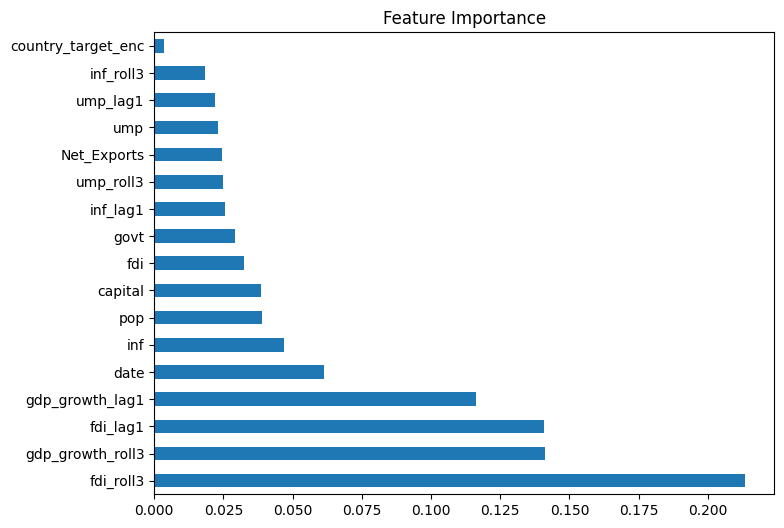

fdi_roll3             0.213325
gdp_growth_roll3      0.141173
fdi_lag1              0.140671
gdp_growth_lag1       0.116171
date                  0.061216
inf                   0.046730
pop                   0.038890
capital               0.038419
fdi                   0.032395
govt                  0.029115
inf_lag1              0.025721
ump_roll3             0.024975
Net_Exports           0.024352
ump                   0.022933
ump_lag1              0.021996
inf_roll3             0.018244
country_target_enc    0.003674
dtype: float32


In [20]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.plot(kind='barh')
plt.title("Feature Importance")
plt.show()

print(importances)

In [21]:
lag_only_cols = [c for c in X_train.columns if 'roll3' not in c]

X_train_lag = X_train[lag_only_cols]
X_test_lag = X_test[lag_only_cols]

X_train_lag_scaled = scaler.fit_transform(X_train_lag.select_dtypes(include=np.number))
X_test_lag_scaled = scaler.transform(X_test_lag.select_dtypes(include=np.number))

grid.fit(X_train_lag_scaled, y_train)
best_model_lag = grid.best_estimator_

y_pred_lag = best_model_lag.predict(X_test_lag_scaled)
print("MAE:", mean_absolute_error(y_test, y_pred_lag))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lag)))
print("R2:", r2_score(y_test, y_pred_lag))

MAE: 4.687678964779296
RMSE: 7.450901705602803
R2: -0.13478227215720318


In [22]:
xgb_simple = XGBRegressor(n_estimators=100, max_depth=2, learning_rate=0.05, random_state=42)
xgb_simple.fit(X_train_scaled, y_train)

y_pred_simple = xgb_simple.predict(X_test_scaled)
print("MAE:", mean_absolute_error(y_test, y_pred_simple))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_simple)))
print("R2:", r2_score(y_test, y_pred_simple))

MAE: 4.251577550790406
RMSE: 6.852566969658185
R2: 0.040154238540502374


In [23]:
baseline_pred = X_test['gdp_growth_lag1']
print("Baseline MAE:", mean_absolute_error(y_test, baseline_pred))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, baseline_pred)))
print("Baseline R2:", r2_score(y_test, baseline_pred))

Baseline MAE: 5.175244824678934
Baseline RMSE: 9.309102279982534
Baseline R2: -0.7713748662517519


# Classification Project

In [30]:
def categorize_growth(x):
    if x < 0:
        return 'Recession'
    elif x < 3:
        return 'Slow Growth'
    else:
        return 'Strong Growth'

df['growth_category'] = df['gdp_growth'].apply(categorize_growth)
df['growth_category'].value_counts()

growth_category
Strong Growth    3010
Slow Growth      1359
Recession         674
Name: count, dtype: int64

In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['growth_category_enc'] = le.fit_transform(df['growth_category'])
print(dict(zip(le.classes_, le.transform(le.classes_))))  # see mapping

{'Recession': np.int64(0), 'Slow Growth': np.int64(1), 'Strong Growth': np.int64(2)}


In [32]:
train = df[df['date'] < 2020]
test = df[df['date'] >= 2020]

feature_cols = [c for c in df.columns if c not in ['gdp_growth','growth_category','growth_category_enc','date']]

X_train, y_train = train[feature_cols], train['growth_category_enc']
X_test, y_test = test[feature_cols], test['growth_category_enc']

In [33]:
X_train_scaled = scaler.fit_transform(X_train.select_dtypes(include=np.number))
X_test_scaled = scaler.transform(X_test.select_dtypes(include=np.number))

In [34]:
from xgboost import XGBClassifier

clf = XGBClassifier(
    n_estimators=100, 
    max_depth=3, 
    learning_rate=0.05, 
    random_state=42,
    scale_pos_weight=None  # not for multiclass, use class_weight approach below
)

# Better: use sample_weight for multiclass imbalance
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
clf.fit(X_train_scaled, y_train, sample_weight=sample_weights)

y_pred = clf.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=le.classes_))

               precision    recall  f1-score   support

    Recession       0.26      0.34      0.30       210
  Slow Growth       0.34      0.43      0.38       251
Strong Growth       0.74      0.55      0.63       519

     accuracy                           0.48       980
    macro avg       0.45      0.44      0.44       980
 weighted avg       0.54      0.48      0.50       980



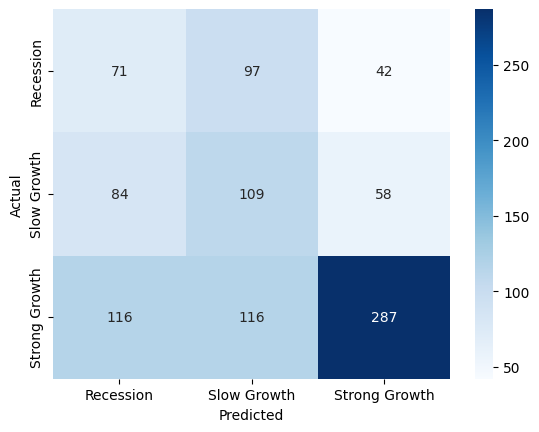

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()